# Data mining — Exploration non supervisée

**BRFSS Heart Analytics** — recherche de profils de population par apprentissage
non supervisé.

## Qu'est-ce que le data mining non supervisé ?

Jusqu'ici, l'analyse exploratoire décrivait les données *variable par variable*
(prévalence par âge, par IMac, etc.). Le data mining va plus loin : il cherche
des **structures cachées** dans les données considérées comme un tout, sans qu'on
lui indique ce qu'il faut trouver.

On parle d'apprentissage **non supervisé** parce qu'on n'utilise **pas** la
variable cible (`heart_disease`). L'algorithme ne sait pas qui est malade : il
regroupe les répondants uniquement selon la ressemblance de leurs profils de
santé. C'est seulement *après* avoir formé les groupes qu'on regarde comment la
maladie s'y répartit. Cette démarche répond à une question différente de celle du
machine learning :

- **Machine learning (supervisé)** : « connaissant le profil, peut-on prédire la
  maladie ? »
- **Data mining (non supervisé)** : « existe-t-il des types de population
  naturellement distincts, et si oui, lesquels sont les plus touchés ? »

## Pourquoi ne pas utiliser la cible pour former les groupes ?

Si on incluait `heart_disease` dans le regroupement, on retrouverait mécaniquement
la séparation malades / sains — un résultat trivial qui n'apprend rien. En
l'excluant, on laisse les **vrais profils de population** émerger (jeunes actifs,
seniors fragiles…), puis on mesure leur risque. Un profil qui se révèle très
exposé sans qu'on ait utilisé la cible pour le construire est une découverte
solide.

## Trois techniques complémentaires

1. **ACP** (analyse en composantes principales) — réduire les 21 variables à
   quelques axes, pour visualiser et comprendre la structure d'ensemble.
2. **Clustering** (k-means et classification hiérarchique) — regrouper les
   répondants en profils homogènes.
3. **t-SNE** — projeter les données en 2D pour *voir* les groupes.

---

In [1]:
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RACINE = Path.cwd().parent.parent
FIGURES = RACINE / "06_rapport" / "figures" / "datamining"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# Graine fixe : résultats reproductibles d'une exécution à l'autre.
GRAINE = 42

# Le nombre de clusters retenu. Justifié à la section 3 (méthode du coude +
# silhouette + interprétabilité). Volontairement > 2 : un découpage en deux
# groupes ne ferait que retrouver la séparation malade / sain, sans détail.
K = 4

def enregistrer(nom):
    plt.savefig(FIGURES / f"{nom}.png")

print("Environnement pret.")

Environnement pret.


## 1. Préparation des données

On charge les 21 variables explicatives depuis l'entrepôt. On met de côté :

- la cible `heart_disease` (on la garde séparément, pour caractériser les groupes
  *après* coup) ;
- les variables dérivées (`risk_factor_count`, etc.) et les drapeaux qualité, qui
  résument d'autres colonnes et fausseraient les distances en comptant deux fois
  la même information.

In [2]:
BASE = RACINE / "02_data_warehouse" / "heart.duckdb"

FEATURES = [
    "high_bp", "high_chol", "chol_check", "bmi", "smoker", "stroke", "diabetes",
    "phys_activity", "fruits", "veggies", "hvy_alcohol", "any_healthcare",
    "no_doc_cost", "gen_hlth", "ment_hlth_days", "phys_hlth_days", "diff_walk",
    "sex", "age_group", "education", "income",
]

with duckdb.connect(str(BASE), read_only=True) as conn:
    df = conn.execute(
        f"SELECT {', '.join(FEATURES)}, heart_disease FROM analytical_base"
    ).df()

cible = df["heart_disease"]
X_brut = df[FEATURES]
print(f"{len(df):,} répondants x {len(FEATURES)} variables")
X_brut.head()

253,680 répondants x 21 variables


,high_bp,high_chol,chol_check,bmi,smoker,stroke,diabetes,phys_activity,fruits,veggies,...,any_healthcare,no_doc_cost,gen_hlth,ment_hlth_days,phys_hlth_days,diff_walk,sex,age_group,education,income
0,1,1,1,40.0,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25.0,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28.0,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27.0,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24.0,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4


### Standardisation : indispensable ici

Toutes les techniques de cette section (ACP, k-means, t-SNE) reposent sur des
**distances** ou des **variances**. Or nos variables ont des échelles très
différentes : l'IMC s'étend sur ~86 unités, les indicateurs binaires sur 1 seule.
Sans mise à l'échelle, l'IMC écraserait tout — non parce qu'il est plus important,
mais parce qu'il est numériquement plus grand (voir la documentation ETL & EDA).

On centre et réduit donc chaque variable : moyenne 0, écart-type 1. Chaque
variable pèse alors autant *a priori*, et c'est la structure des données, pas les
unités de mesure, qui gouverne les résultats.

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X_brut)

verif = pd.DataFrame({
    "moyenne (avant)": X_brut.mean(),
    "écart-type (avant)": X_brut.std(),
    "moyenne (après)": X.mean(axis=0),
    "écart-type (après)": X.std(axis=0),
}).round(2)
verif

,moyenne (avant),écart-type (avant),moyenne (après),écart-type (après)
high_bp,0.43,0.49,0.0,1.0
high_chol,0.42,0.49,0.0,1.0
chol_check,0.96,0.19,-0.0,1.0
bmi,28.38,6.61,0.0,1.0
smoker,0.44,0.50,-0.0,1.0
stroke,0.04,0.20,0.0,1.0
diabetes,0.30,0.70,0.0,1.0
phys_activity,0.76,0.43,-0.0,1.0
fruits,0.63,0.48,-0.0,1.0
veggies,0.81,0.39,-0.0,1.0


## 2. Analyse en composantes principales (ACP)

L'ACP cherche à **résumer** 21 variables par un plus petit nombre d'axes (les
*composantes principales*), en perdant le moins d'information possible.
Concrètement, elle trouve les directions selon lesquelles les données varient le
plus. La première composante (CP1) est l'axe de plus grande variance, la deuxième
(CP2) le suivant en étant perpendiculaire à CP1, et ainsi de suite.

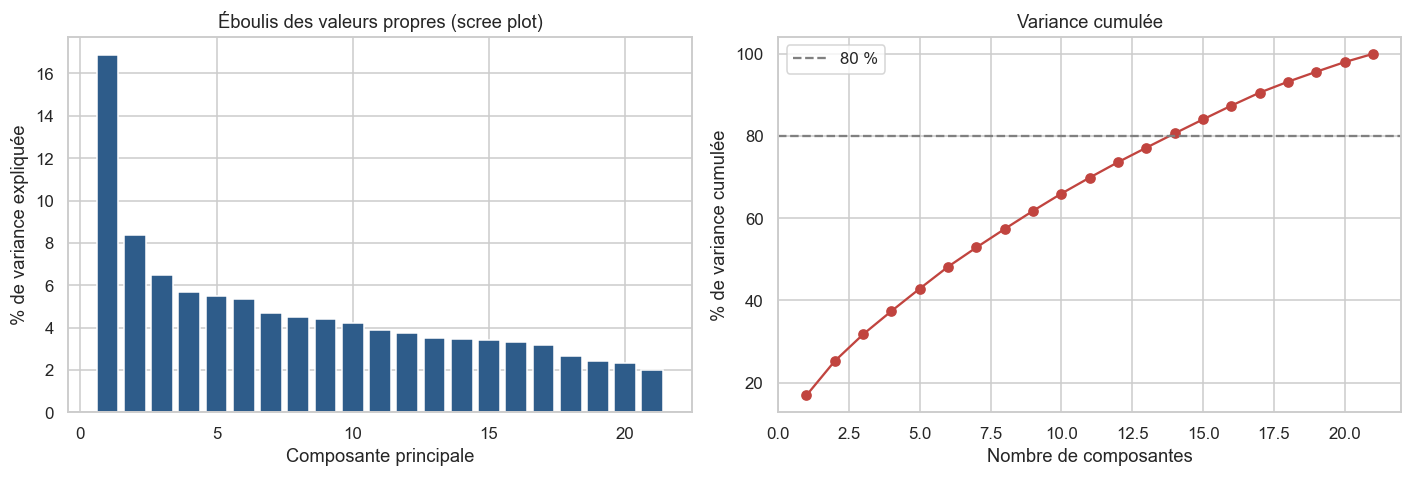

CP1 : 16.9 %   CP1+CP2 : 25.2 %
Composantes pour atteindre 80 % : 14


In [4]:
acp = PCA()
composantes = acp.fit_transform(X)

variance = acp.explained_variance_ratio_ * 100
cumul = np.cumsum(variance)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(variance) + 1), variance, color="#2E5C8A")
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("% de variance expliquée")
axes[0].set_title("Éboulis des valeurs propres (scree plot)")

axes[1].plot(range(1, len(cumul) + 1), cumul, "o-", color="#C1443F")
axes[1].axhline(80, ls="--", c="grey", label="80 %")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("% de variance cumulée")
axes[1].set_title("Variance cumulée")
axes[1].legend()

plt.tight_layout()
enregistrer("01_acp_variance")
plt.show()

print(f"CP1 : {variance[0]:.1f} %   CP1+CP2 : {cumul[1]:.1f} %")
print(f"Composantes pour atteindre 80 % : {np.argmax(cumul >= 80) + 1}")

### Lecture — un résultat important et honnête

La première composante ne capte que **~17 %** de la variance, et il faut **14
composantes** pour atteindre 80 %. Autrement dit, l'ACP **compresse mal** ces
données : il n'existe pas deux ou trois axes dominants qui résumeraient tout.

Ce n'est pas un échec, c'est une information. La cause est la nature des données :
21 variables en grande majorité **binaires** et peu corrélées entre elles (on
l'avait vu dans l'EDA — corrélations de Pearson toutes faibles). Chaque variable
apporte une part d'information propre ; il n'y a pas de redondance massive à
éliminer. La structure est **intrinsèquement multidimensionnelle**.

**Conséquence** : on utilisera l'ACP pour *visualiser* (le plan CP1-CP2 reste utile
pour se repérer) et pour *interpréter* les axes, mais pas comme un prétraitement de
compression. Le clustering, lui, se fera sur les 21 variables standardisées, sans
perte d'information.

### Cercle des corrélations

Le cercle des corrélations montre comment chaque variable d'origine se projette
sur le plan des deux premières composantes. Deux variables dont les flèches
pointent dans la même direction sont corrélées ; une flèche longue signifie que la
variable est bien représentée par ce plan.

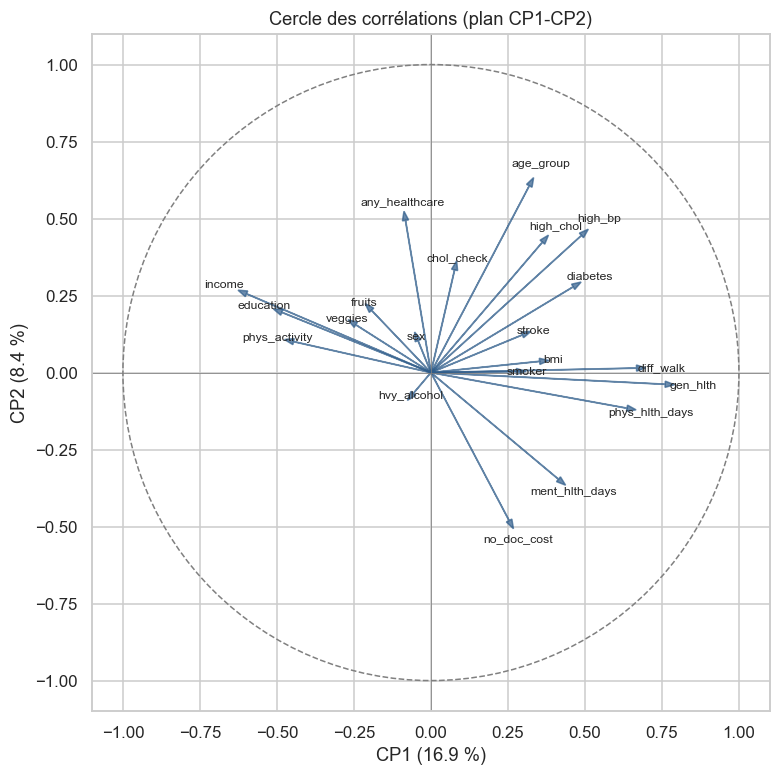

In [5]:
# Coordonnées des variables sur CP1 et CP2 (les "loadings")
charges = acp.components_[:2].T * np.sqrt(acp.explained_variance_[:2])

fig, ax = plt.subplots(figsize=(8, 8))
cercle = plt.Circle((0, 0), 1, color="grey", fill=False, ls="--")
ax.add_patch(cercle)

for i, var in enumerate(FEATURES):
    ax.arrow(0, 0, charges[i, 0], charges[i, 1], head_width=0.02,
             color="#2E5C8A", alpha=0.7)
    ax.text(charges[i, 0] * 1.12, charges[i, 1] * 1.12, var, fontsize=8,
            ha="center", va="center")

ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f"CP1 ({variance[0]:.1f} %)")
ax.set_ylabel(f"CP2 ({variance[1]:.1f} %)")
ax.set_title("Cercle des corrélations (plan CP1-CP2)")
ax.set_aspect("equal")
enregistrer("02_cercle_correlations")
plt.show()

**Interprétation des axes** (d'après le cercle ci-dessus) :

- **CP1** (axe horizontal) est un axe de **charge morbide globale**. À droite se
  regroupent la mauvaise santé perçue (`gen_hlth`), la difficulté à marcher, les
  jours de mal-être physique, le diabète, l'hypertension et le cholestérol — le
  pôle « fragilité ». À gauche, opposés, le revenu, le niveau d'études et
  l'activité physique — le pôle « bonne santé / aisance ». Cet axe seul résume donc
  déjà le gradient sain ↔ malade.
- **CP2** (axe vertical) est un axe d'**âge et de rapport au système de soins**. En
  haut : l'âge, l'hypertension et le cholestérol, la couverture santé et le
  dépistage (`any_healthcare`, `chol_check`) — des personnes âgées, assurées, aux
  pathologies suivies. En bas, à l'opposé : le renoncement aux soins pour raison
  financière (`no_doc_cost`) et le mal-être mental — des personnes plus jeunes et
  en difficulté d'accès.

Deux enseignements se dégagent déjà. D'abord, un ensemble de facteurs de risque
(`high_bp`, `high_chol`, `diabetes`, `diff_walk`) pointent dans la même direction :
ils évoluent ensemble, ce qui présage des profils de population cohérents. Ensuite,
l'axe CP2 fait apparaître, dès l'ACP, la dimension de l'**accès aux soins** — que le
clustering isolera nettement (le profil des non-assurés).

### Projection des individus

On projette les répondants sur le plan CP1-CP2, coloriés selon leur statut
cardiaque (que l'ACP n'a **pas** utilisé). Si les malades se concentrent dans une
région, c'est que la structure géométrique des données porte déjà le signal de la
maladie.

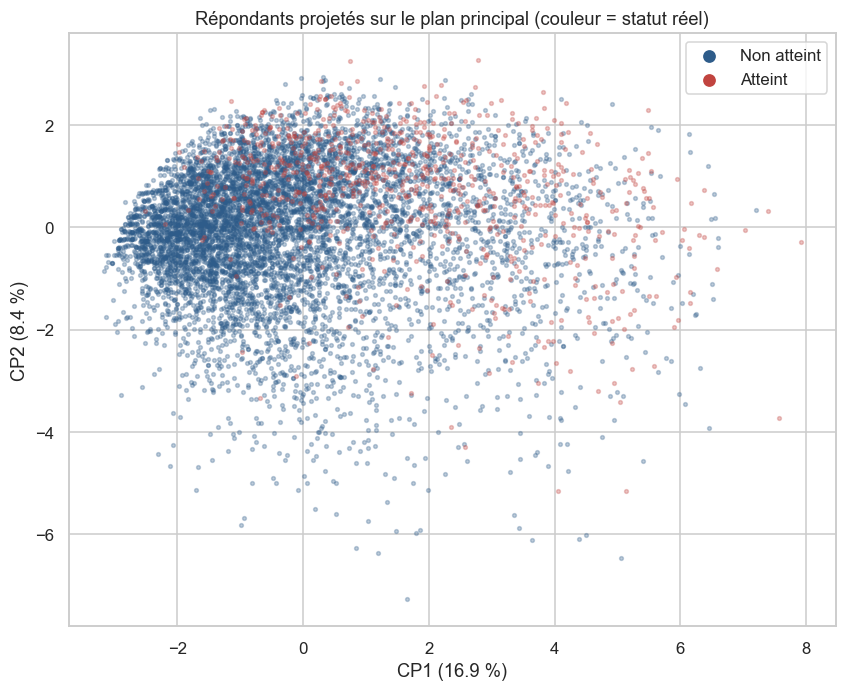

In [6]:
# Échantillon pour un nuage lisible (253k points seraient illisibles)
rng = np.random.default_rng(GRAINE)
ech = rng.choice(len(X), 8000, replace=False)

fig, ax = plt.subplots(figsize=(9, 7))
for statut, couleur, nom in [(0, "#2E5C8A", "Non atteint"), (1, "#C1443F", "Atteint")]:
    masque = cible.values[ech] == statut
    ax.scatter(composantes[ech][masque, 0], composantes[ech][masque, 1],
               s=6, alpha=0.3, c=couleur, label=nom)
ax.set_xlabel(f"CP1 ({variance[0]:.1f} %)")
ax.set_ylabel(f"CP2 ({variance[1]:.1f} %)")
ax.set_title("Répondants projetés sur le plan principal (couleur = statut réel)")
leg = ax.legend(markerscale=3)
for lh in leg.legend_handles:
    lh.set_alpha(1)
enregistrer("03_acp_projection")
plt.show()

On observe un **dégradé** plutôt que deux nuages séparés : les personnes atteintes
se déplacent vers les valeurs élevées de CP1 (le pôle « charge morbide »), sans
former un bloc isolé. Cela confirme deux choses vues plus tôt : le signal existe,
mais il est **diffus et non linéaire** — d'où l'intérêt d'un clustering pour
découper cette structure continue en profils exploitables.

---

## 3. Combien de groupes ? Le choix de k

Le k-means exige de fixer à l'avance le nombre de groupes, `k`. Le choisir au
hasard n'aurait aucun sens : on utilise deux critères classiques.

- **Méthode du coude** : on trace l'inertie (la dispersion interne des clusters)
  en fonction de `k`. Elle diminue toujours quand `k` augmente ; on cherche le
  « coude », le point après lequel ajouter un groupe n'apporte plus grand-chose.
- **Score de silhouette** : mesure à quel point chaque point est bien dans son
  groupe plutôt que dans un autre (entre -1 et 1, plus haut est mieux).

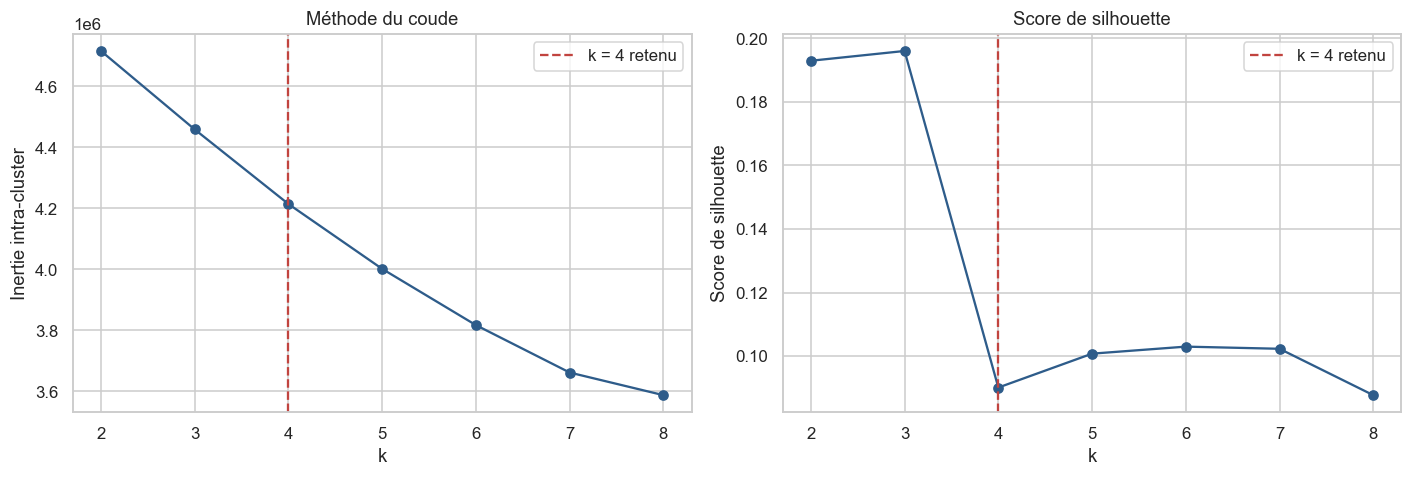

  k=2 : inertie=   4715378  silhouette=0.193
  k=3 : inertie=   4458053  silhouette=0.196
  k=4 : inertie=   4213518  silhouette=0.090
  k=5 : inertie=   4000840  silhouette=0.101
  k=6 : inertie=   3816465  silhouette=0.103
  k=7 : inertie=   3661018  silhouette=0.102
  k=8 : inertie=   3586851  silhouette=0.088


In [7]:
ks = range(2, 9)
inerties, silhouettes = [], []

# La silhouette est coûteuse (O(n^2)) : on l'évalue sur un échantillon.
ech_sil = rng.choice(len(X), 10000, replace=False)

for k in ks:
    km = KMeans(n_clusters=k, random_state=GRAINE, n_init=10).fit(X)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X[ech_sil], km.labels_[ech_sil]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(ks), inerties, "o-", color="#2E5C8A")
axes[0].axvline(K, ls="--", c="#C1443F", label=f"k = {K} retenu")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie intra-cluster")
axes[0].set_title("Méthode du coude")
axes[0].legend()

axes[1].plot(list(ks), silhouettes, "o-", color="#2E5C8A")
axes[1].axvline(K, ls="--", c="#C1443F", label=f"k = {K} retenu")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_title("Score de silhouette")
axes[1].legend()

plt.tight_layout()
enregistrer("04_choix_k")
plt.show()

for k, inr, sil in zip(ks, inerties, silhouettes):
    print(f"  k={k} : inertie={inr:>10.0f}  silhouette={sil:.3f}")

### Justification du choix : k = 4

Les deux critères ne pointent pas vers la même valeur, et il faut en discuter
honnêtement.

- La **silhouette** est maximale pour k=2 ou k=3, puis baisse. Mais **toutes** les
  valeurs sont faibles (~0,1 à 0,2). C'est attendu : avec des variables binaires,
  les groupes se **chevauchent** fortement — il n'y a pas de clusters bien séparés
  et sphériques comme la silhouette les récompense. Ici, la silhouette n'est donc
  **pas un juge fiable**.
- La **méthode du coude** montre une décroissance régulière, sans coude franc :
  chaque groupe supplémentaire continue de réduire l'inertie de façon appréciable
  jusqu'à k≈5-6.

Dans ce contexte, le critère décisif devient l'**interprétabilité**. Un k=2 se
contenterait de séparer « plutôt sains » et « plutôt fragiles » — un découpage
binaire trop grossier, qui n'apprend rien de plus que la cible elle-même. En
retenant **k=4**, on obtient quatre profils de population distincts et lisibles
(on le vérifie à la section suivante), avec un gradient de risque étendu. C'est le
bon compromis entre finesse et clarté : assez de détail pour raconter une histoire,
assez peu de groupes pour qu'ils restent nommables.

> **Principe** : sur des données réelles où les critères statistiques sont peu
> tranchés, on choisit le nombre de clusters qui produit des groupes **utiles et
> interprétables**, pas seulement celui qui optimise un score. La valeur d'un
> clustering se juge à ce qu'on peut en dire.

## 4. K-means : les profils de population

On applique le k-means avec k=4 sur les 253 680 répondants. Chaque répondant est
affecté au groupe dont le centre (le profil moyen) est le plus proche du sien.

In [8]:
kmeans = KMeans(n_clusters=K, random_state=GRAINE, n_init=10)
labels = kmeans.fit_predict(X)
df["cluster"] = labels

# On ordonne les clusters par taux de maladie croissant, pour un affichage stable
# et une lecture en gradient de risque.
taux_par_cluster = df.groupby("cluster")["heart_disease"].mean().sort_values()
ordre = {ancien: nouveau for nouveau, ancien in enumerate(taux_par_cluster.index)}
df["profil"] = df["cluster"].map(ordre)

tailles = df["profil"].value_counts().sort_index()
taux = df.groupby("profil")["heart_disease"].mean() * 100

resume = pd.DataFrame({
    "effectif": tailles,
    "part (%)": (tailles / len(df) * 100).round(1),
    "taux maladie (%)": taux.round(1),
})
resume

,effectif,part (%),taux maladie (%)
profil,,,
0,113279,44.7,1.6
1,12269,4.8,6.6
2,87922,34.7,13.0
3,40210,15.9,24.5


### Profil moyen de chaque groupe

Pour comprendre *qui* compose chaque groupe, on regarde la moyenne des variables
clés par profil. Les valeurs sont les moyennes réelles (non standardisées), plus
faciles à lire.

In [9]:
variables_cle = [
    "age_group", "gen_hlth", "bmi", "high_bp", "high_chol", "diabetes",
    "diff_walk", "stroke", "smoker", "phys_activity", "income", "education",
]
profils = df.groupby("profil")[variables_cle].mean().round(2)
profils.insert(0, "taux_maladie_%", taux.round(1))
profils

,taux_maladie_%,age_group,gen_hlth,bmi,high_bp,high_chol,diabetes,diff_walk,stroke,smoker,phys_activity,income,education
profil,,,,,,,,,,,,,
0,1.6,6.57,1.94,26.540001,0.08,0.19,0.03,0.02,0.01,0.31,0.88,6.92,5.41
1,6.6,6.14,2.68,28.840000,0.34,0.33,0.23,0.15,0.03,0.49,0.69,4.63,4.52
2,13.0,9.69,2.59,29.270000,0.78,0.65,0.44,0.08,0.04,0.53,0.75,6.00,4.92
3,24.5,9.12,3.90,31.480000,0.68,0.60,0.74,0.78,0.15,0.60,0.45,4.18,4.48


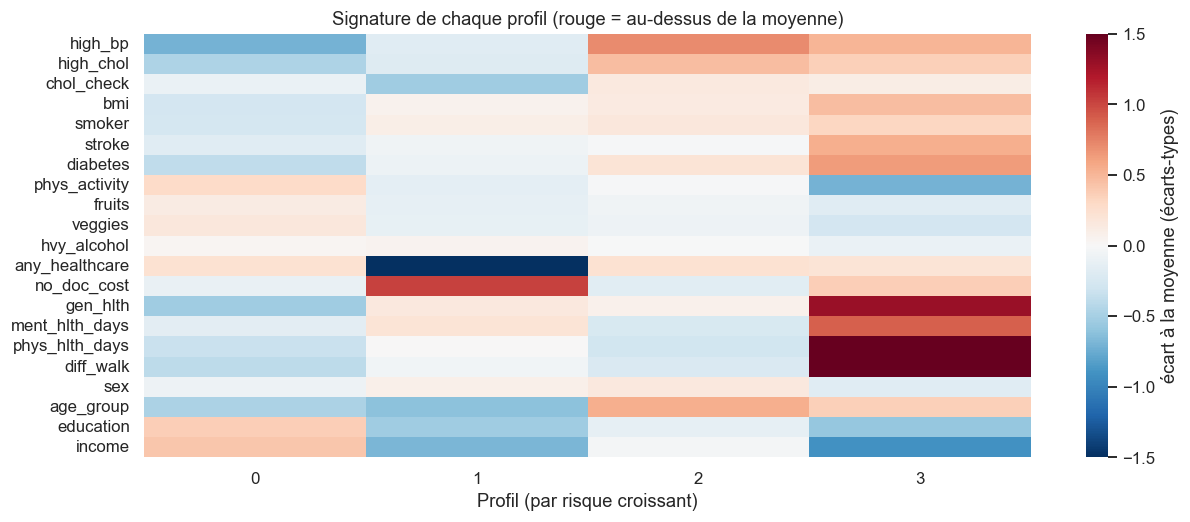

In [10]:
# Carte de chaleur des profils standardisés : lecture visuelle des contrastes.
# (moyennes standardisées : rouge = au-dessus de la moyenne générale, bleu = en dessous)
profils_std = df.groupby("profil")[FEATURES].mean()
profils_std = (profils_std - X_brut.mean()) / X_brut.std()

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(profils_std.T, cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5,
            annot=False, cbar_kws={"label": "écart à la moyenne (écarts-types)"},
            ax=ax)
ax.set_xlabel("Profil (par risque croissant)")
ax.set_ylabel("")
ax.set_title("Signature de chaque profil (rouge = au-dessus de la moyenne)")
enregistrer("05_kmeans_heatmap")
plt.show()

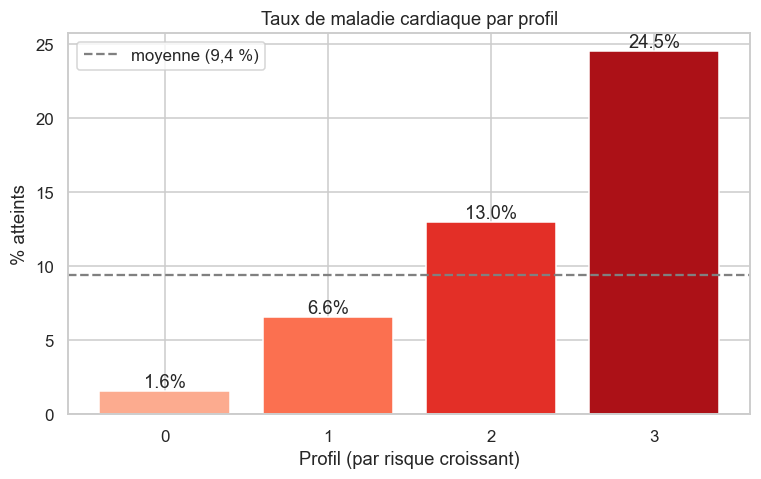

In [11]:
# Taux de maladie par profil
fig, ax = plt.subplots(figsize=(8, 4.5))
couleurs = plt.cm.Reds(np.linspace(0.30, 0.85, K))
barres = ax.bar(taux.index.astype(str), taux.values, color=couleurs)
ax.axhline(cible.mean() * 100, ls="--", c="grey", label="moyenne (9,4 %)")
ax.set_xlabel("Profil (par risque croissant)")
ax.set_ylabel("% atteints")
ax.set_title("Taux de maladie cardiaque par profil")
ax.legend()
for b, v in zip(barres, taux.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}%", ha="center", va="bottom")
enregistrer("06_kmeans_risque")
plt.show()

### Interprétation : quatre profils de population

En croisant le tableau des moyennes et la carte de chaleur, les quatre groupes se
lisent clairement. Ils sont ici ordonnés par risque croissant.

**Profil 0 — Jeunes actifs en bonne santé** (~1,6 % de risque, le plus grand
groupe). Âge bas, excellente santé perçue, IMC modéré, très peu de facteurs de
risque, forte activité physique, revenus et études élevés. C'est la population de
référence, quasiment épargnée.

**Profil 1 — Adultes non assurés** (~6,6 %). Signature frappante et **sociale**,
pas médicale : **aucun** membre de ce groupe n'a de couverture santé (0 %, contre
95 % dans la population), et 37 % ont renoncé à consulter un médecin pour raison
financière (contre 8 %). Ce sont des adultes plutôt jeunes, aux revenus et au
niveau d'études plus bas. Leur risque (6,6 %) est modéré mais notable compte tenu
de leur jeunesse — le défaut d'accès aux soins pèse. Que le clustering ait isolé
ce groupe à partir de variables surtout médicales est remarquable : il a retrouvé
une fracture d'**accès au système de santé**.

**Profil 2 — Seniors autonomes** (~13 %). Personnes âgées mais **en forme** :
hypertension et cholestérol fréquents (souvent traités, tous assurés), mais bonne
mobilité (peu de difficulté à marcher), activité physique maintenue, revenus
corrects. L'âge les expose, mais ils compensent par un bon état fonctionnel.

**Profil 3 — Seniors multi-morbides fragiles** (~24,5 %, le risque le plus élevé).
Cumul de pathologies : diabète fréquent, forte difficulté à marcher, mauvaise
santé perçue, IMC élevé, AVC plus fréquents, faible activité, revenus plus bas.
C'est le groupe cible prioritaire pour toute action de prévention.

> Les noms sont interprétatifs : ils résument les caractéristiques dominantes de
> chaque groupe, lesquelles sont visibles dans le tableau des moyennes ci-dessus.

**Ce que cela apprend.** Le clustering, qui n'a jamais vu la variable maladie, a
séparé la population en groupes dont le risque va de **1,6 % à 24,5 %** — un
rapport de 1 à 15. La géométrie des profils de santé porte donc, à elle seule, une
grande partie de l'information sur la maladie. Deux enseignements ressortent :

- Il distingue **deux populations âgées** que l'âge seul confondrait : les seniors
  **autonomes** (13 %) et les seniors **fragiles** (24,5 %). C'est la mobilité et
  le cumul de pathologies, plus que l'âge, qui font la différence.
- Il a isolé un groupe défini par l'**accès aux soins** (les non-assurés), preuve
  que les déterminants sociaux structurent la population au même titre que les
  facteurs cliniques.

---

## 5. Classification ascendante hiérarchique (CAH)

Le k-means impose le nombre de groupes. La **CAH** procède autrement : elle part de
chaque individu isolé et fusionne progressivement les plus proches, jusqu'à n'avoir
qu'un seul groupe. Le résultat se lit sur un **dendrogramme** — un arbre dont la
hauteur des fusions indique la dissimilarité. Cela permet de **vérifier**, par une
méthode indépendante, si la structure en 4 groupes est cohérente.

La CAH a un coût mémoire en O(n²) : impossible sur 253 680 lignes. On travaille sur
un **échantillon aléatoire** de 3 000 répondants, suffisant pour révéler la
structure d'ensemble.

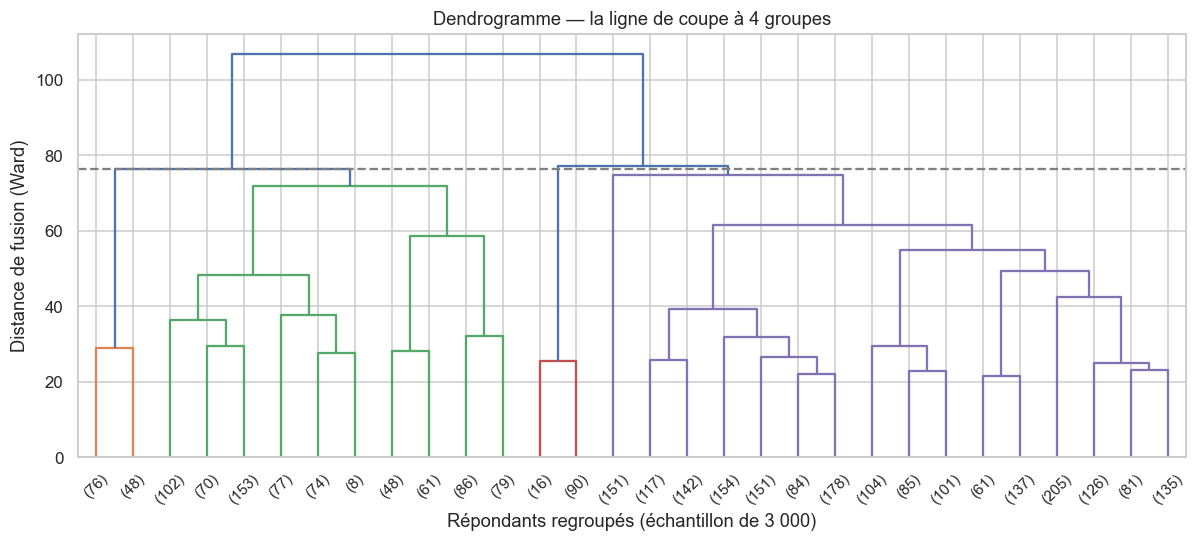

In [12]:
ech_cah = rng.choice(len(X), 3000, replace=False)
X_cah = X[ech_cah]

# Méthode de Ward : minimise la variance intra-cluster à chaque fusion,
# cohérente avec le critère du k-means.
liens = linkage(X_cah, method="ward")

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(liens, truncate_mode="lastp", p=30, ax=ax,
           color_threshold=liens[-(K - 1), 2])
ax.set_xlabel("Répondants regroupés (échantillon de 3 000)")
ax.set_ylabel("Distance de fusion (Ward)")
ax.set_title(f"Dendrogramme — la ligne de coupe à {K} groupes")
ax.axhline(liens[-(K - 1), 2], ls="--", c="grey")
enregistrer("07_cah_dendrogramme")
plt.show()

**Lecture.** En coupant l'arbre à la hauteur indiquée (trait pointillé), on obtient
un petit nombre de branches principales. Le dendrogramme montre des regroupements
qui se forment à des hauteurs nettes, cohérents avec un découpage en quelques
groupes — ce qui **conforte** le choix du k-means. Les deux méthodes, de logiques
différentes, convergent vers une même idée : la population se structure en une
poignée de profils, pas en deux blocs ni en une multitude.

In [13]:
# Comparaison : combien de groupes la CAH forme-t-elle, et à quels taux de maladie ?
cah = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_cah = cah.fit_predict(X_cah)

comp = pd.DataFrame({
    "groupe_cah": labels_cah,
    "malade": cible.values[ech_cah],
})
resume_cah = comp.groupby("groupe_cah").agg(
    effectif=("malade", "size"),
    taux_maladie=("malade", lambda s: round(s.mean() * 100, 1)),
).sort_values("taux_maladie")
resume_cah

,effectif,taux_maladie
groupe_cah,,
2,106,2.8
0,2012,5.8
1,758,14.6
3,124,41.9


La CAH retrouve elle aussi des groupes aux taux de maladie très contrastés, du plus
épargné au plus exposé. Les effectifs et les taux exacts diffèrent du k-means (ce
sont des algorithmes distincts, sur un échantillon), mais la **structure est la
même** : un gradient de profils allant des populations saines aux populations
fragiles.

---

## 6. Visualisation par t-SNE

L'ACP cherchait des axes linéaires. Le **t-SNE** est une technique non linéaire
dédiée à la **visualisation** : il projette les données en 2D en s'efforçant de
garder proches, sur l'image, les points qui étaient proches dans l'espace à 21
dimensions. C'est un excellent moyen de *voir* si les groupes du clustering
correspondent à des régions réellement distinctes.

Le t-SNE est lent : on l'applique sur un échantillon de 5 000 points.

In [14]:
ech_tsne = rng.choice(len(X), 5000, replace=False)
X_tsne_in = X[ech_tsne]

tsne = TSNE(n_components=2, perplexity=40, init="pca",
            random_state=GRAINE, max_iter=1000)
proj = tsne.fit_transform(X_tsne_in)
print("t-SNE terminé :", proj.shape)

t-SNE terminé : (5000, 2)


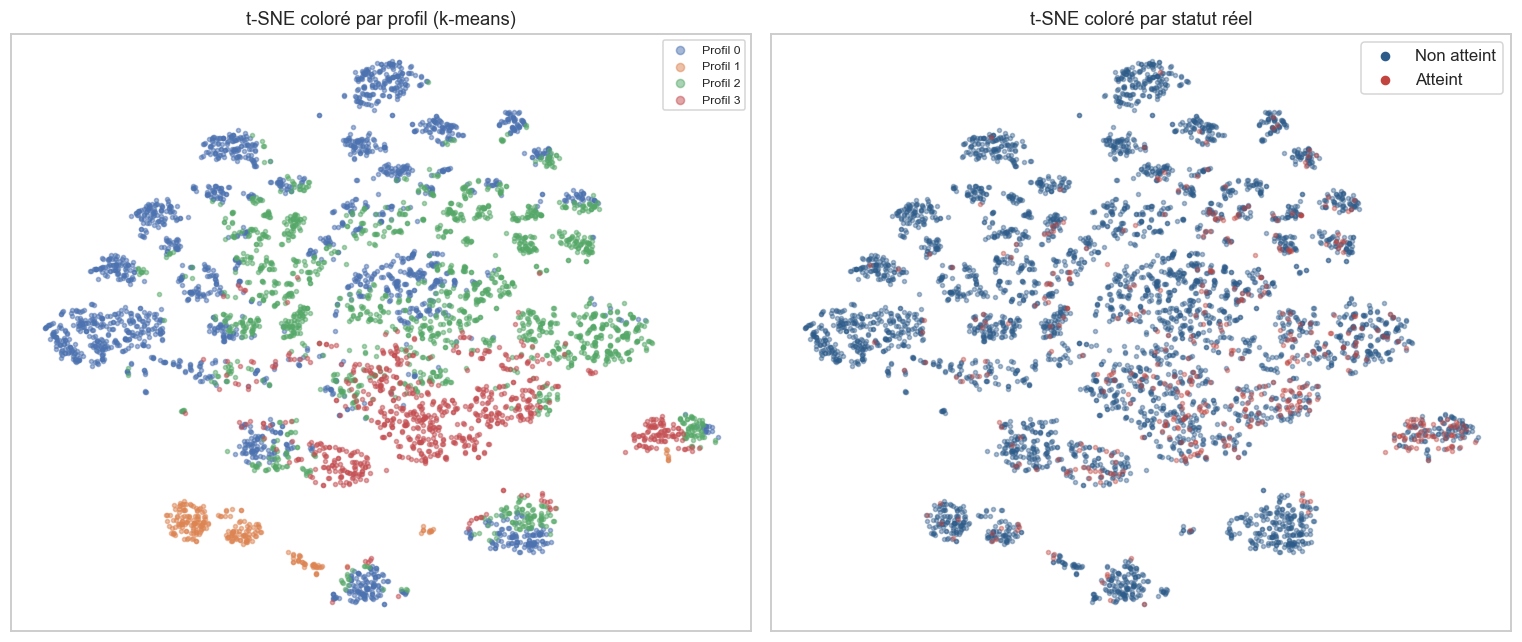

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) coloré par profil k-means
for p in range(K):
    m = df["profil"].values[ech_tsne] == p
    axes[0].scatter(proj[m, 0], proj[m, 1], s=7, alpha=0.5, label=f"Profil {p}")
axes[0].set_title("t-SNE coloré par profil (k-means)")
axes[0].legend(markerscale=2, fontsize=8)
axes[0].set_xticks([]); axes[0].set_yticks([])

# (b) coloré par statut cardiaque réel
for statut, couleur, nom in [(0, "#2E5C8A", "Non atteint"), (1, "#C1443F", "Atteint")]:
    m = cible.values[ech_tsne] == statut
    axes[1].scatter(proj[m, 0], proj[m, 1], s=7, alpha=0.4, c=couleur, label=nom)
axes[1].set_title("t-SNE coloré par statut réel")
leg = axes[1].legend(markerscale=2)
for lh in leg.legend_handles:
    lh.set_alpha(1)
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
enregistrer("08_tsne")
plt.show()

**Lecture des deux images.**

- À **gauche** (couleur = profil k-means) : les profils occupent des régions
  cohérentes. Les seniors autonomes et fragiles (profils 2 et 3) se chevauchent en
  partie — on l'avait anticipé (silhouette faible). En revanche, le profil des
  **non-assurés** (profil 1) forme un **îlot nettement isolé** en marge de la
  carte : ce groupe, défini par l'absence de couverture santé, est le plus
  distinct de tous. Le t-SNE valide donc de façon indépendante cette découverte du
  clustering.
- À **droite** (couleur = maladie réelle, jamais utilisée) : les personnes
  atteintes se concentrent dans les mêmes régions que les profils à haut risque de
  l'image de gauche. La correspondance entre la géométrie des données et la maladie
  saute aux yeux, alors qu'aucune des deux projections n'a utilisé la cible.

C'est la confirmation visuelle de tout le chapitre : il existe des profils de
population identifiables, et leur position dans l'espace des variables prédit en
grande partie leur exposition à la maladie.

---

## 7. Synthèse

### Ce que l'exploration non supervisée a révélé

| Résultat | Constat |
|---|---|
| **ACP** | Compression faible (14 CP pour 80 %) : structure multidimensionnelle, variables peu redondantes. L'ACP sert à visualiser, pas à réduire. |
| **Nombre de groupes** | k=4 retenu : la silhouette (peu fiable ici) préfère k=2-3, mais l'interprétabilité et le coude justifient un découpage plus fin. |
| **k-means** | Quatre profils de population, risque de **1,6 % à 24,5 %**, construits **sans** la cible. |
| **CAH** | Structure cohérente confirmée par une méthode indépendante. |
| **t-SNE** | Les profils occupent des régions distinctes ; les malades s'y concentrent comme attendu. |

### Les quatre profils

1. **Jeunes actifs en bonne santé** — risque minimal (~1,6 %).
2. **Adultes non assurés** — sans couverture santé, plus jeunes et modestes (~6,6 %).
3. **Seniors autonomes** — âgés mais fonctionnels (~13 %).
4. **Seniors multi-morbides fragiles** — cumul de pathologies (~24,5 %).

### Les découvertes principales

- Le clustering distingue **deux populations âgées** que l'âge seul confondrait :
  les seniors **autonomes** (13 %) et les seniors **fragiles** (24,5 %). Ce qui les
  sépare, ce n'est pas l'âge mais la **mobilité** (difficulté à marcher), le
  **diabète** et le **cumul de pathologies**. Enseignement directement actionnable :
  une prévention devrait cibler la fragilité fonctionnelle, pas seulement l'âge.
- À partir de variables surtout médicales, il a isolé le groupe des **non-assurés**
  — une fracture d'**accès aux soins**. Les déterminants sociaux (couverture santé,
  revenu) structurent la population autant que les facteurs cliniques.

### Ce que cela apporte au machine learning (module suivant)

- Le signal est **réel mais diffus et non linéaire** (ACP peu compressive,
  chevauchement des groupes). Cela confirme que des modèles **non linéaires**
  (arbres, ensembles) devraient surpasser une régression logistique simple.
- Les profils suggèrent des **interactions** (âge × mobilité, âge × diabète) que le
  modèle devra capter.
- Aucune variable ne domine à elle seule : c'est la **combinaison** des facteurs qui
  fait le risque — argument supplémentaire pour des modèles capables de gérer les
  interactions.